Generalised Profiling Tutorial<br>
Convergence Study

Alexander Johnston & James Bennett<br>
School of Mathematical Sciences, Queensland University of Technology<br>
ARC Centre of Excellence for the Mathematical Analysis of Cellular Systems<br>
a44.johnston@qut.edu.au / j39.bennett@qut.edu.au

- Normalised for dimensionless weights.
- Enforces model as `linear terms at update = nonlinear terms at last iteration'
- Toggle options:
  - set `use_LV_data' to 1 to use the Lotka--Volterra dataset appearing in the paper
  - BLARGH

In [1]:
#Load packages for calculations..
using DelimitedFiles, DifferentialEquations, SparseArrays, Random, Distributions, NLopt, BSplineKit, LinearAlgebra, OffsetArrays, LeastSquaresOptim
#...for housekeeping...
using IJuliaBell, ProgressMeter
#...and for graphics.
using LaTeXStrings, ColorSchemes, GLMakie

wongc = Makie.wong_colors();
GLMakie.activate!()
set_theme!(fonts = (; regular = "Computer Modern", bold = "Computer Modern"),fontsize = 24)

Set `use_paper_dataset` to 1 to use data from Alex's paper. Otherwise, leave as zero to generate a new synthetic dataset.

In [2]:
#Toggle inputs.
use_paper_dataset = 1 #1 means use the dataset from the paper, 0 means generate a new synthetic dataset
use_new_norm = 0; #1 means use the maximally linear normalisation.
use_natural_splines = 1; #1 means use cardinal b-splines with natural boundary conditions for the initial unregularised fit.

In [50]:
if use_paper_dataset == 1
    #DO NOT ALTER THIS PART OF THE 'IF' BLOCK.
    
    #Model parameters
    α = 1; δ = 1;
    a = [α, δ];

    #Initial conditions
    x0 = 1; y0 = 0.5;
    ic=[x0, y0]

    #Number of synthetic data points (each)
    N_data = 41;

    #Ratio of number of points in the spline grid to the number of points in the synthetic data set 
    grid_ratio = 10;

    #Number of B-Splines
    df = N_data - 1;

    #Discretisation grid size for spline
    N_t = grid_ratio*(N_data - 1)+1;

    #Time domain over which to create synthetic data.
    t_start = 0; t_end = 25;
    t_true = LinRange(t_start, t_end, N_t);

    #Standard deviation of additive Gaussian noise used to generate the synthetic data
    sigma=0.05;
    
    #Set bounds on allowable parameters in numerical solver.
    αmin= 0.8; αmax = 1.3;
    δmin=0.8; δmax=1.3;

    #Provide an initial guess of θ.
    alpha_test = 1.1;
    delta_test = 0.85;

    t_data = readdlm("LV_t", '\t', Float64, '\n')[:]
    x_data = readdlm("LV_x", '\t', Float64, '\n')[:]
    y_data = readdlm("LV_y", '\t', Float64, '\n')[:]
else
    #YOU **CAN** ALTER THESE INPUTS to generate a new synthetic dataset.
    #Model parameters
    α = 1; δ = 1;
    a = [α, δ];

    #Initial conditions
    x0 = 1; y0 = 0.5;
    ic=[x0, y0]

    #Number of synthetic data points (each)
    N_data = 41;

    #Ratio of number of points in the spline grid to the number of points in the synthetic data set 
    grid_ratio = 10;

    #Discretisation grid size for spline
    N_t = grid_ratio*(N_data - 1)+1;

    #Time domain over which to create synthetic data.
    t_start = 0; t_end = 25;
    t_true = LinRange(t_start, t_end, N_t);

    #Standard deviation of additive Gaussian noise used to generate the synthetic data
    sigma = .05 ;
    
    #Provide an initial guess of θ.
    alpha_test = 1.1;
    delta_test = 0.9;

    #Create synthetic data for the Lotka-Volterra predator-prey model.

    function process_model(t_true,ic,a)
        #Lotka-Volterra predator-prey equations
        function Lotka_Volterra!(du,u,a,t)
            du[1]=a[1]*u[1] - u[1]*u[2]; 
            du[2]=a[2]*u[1]*u[2] - u[2];
        end

        function odesolver(t,ic,a)
            tspan=(0.0,maximum(t))
            prob=ODEProblem(Lotka_Volterra!,ic,tspan, a)
            alg=Tsit5()
            sol=solve(prob,alg,saveat=t);
            return sol
        end

        sol = odesolver(t_true,ic,a) #Solves the ODEs on t_true.
        return (sol[1,:],sol[2,:]) #(x_true, y_true)
    end

    function noise_model(t,x,y,sigma,grid_ratio)
        #Make a sub-sampled t grid and observations.
        t_sub = [];
        x_sub = [];
        y_sub = [];
        for i ∈ eachindex(t_true)
            if (i-1)%grid_ratio == 0
                push!(t_sub, t[i])
                push!(x_sub, x[i])
                push!(y_sub, y[i])
            end
        end
        #Create stochastic data using additive Gaussian noise applied at each data point for the true solution
        dist=Normal(0,sigma);
        x_data = x_sub + rand(dist,size(x_sub))
        y_data = y_sub + rand(dist,size(y_sub))
        return (t_sub,x_data,y_data)
    end

    (x_true,y_true) = process_model(t_true,ic,a);
    (t_data,x_data,y_data) = noise_model(t_true,x_true,y_true,sigma,grid_ratio);
end

#Set bounds on allowable parameters in numerical solver.
αmin = 0.8; αmax = 1.30;
δmin = 0.8; δmax = 1.30;
#Package up some of the inputs.
lb=[αmin,δmin]
ub=[αmax,δmax]
a_test = [alpha_test, delta_test];

In [51]:
#Implement some quick sanity checks to make sure user inputs are sensible.
if alpha_test ≥ αmax || delta_test ≥ δmax
    @bell error("Initial parameter guesses are above bounds set for numerical solver.")
end
if alpha_test ≤ αmin || delta_test ≤ δmin
    @bell error("Initial parameter guesses are below bounds set for numerical solver.")
end

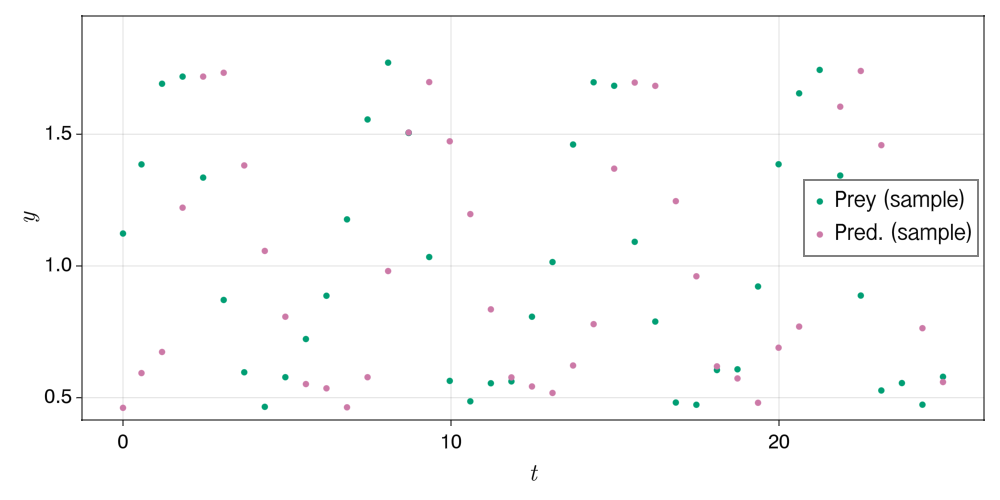

In [52]:
#Plot the synthetic data.
fig = Figure(size = (1000, 500))
let ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"y")
    if use_paper_dataset ≠ 1
        lines!(t_true,x_true,color=wongc[3],label="Prey (true)")
        lines!(t_true,y_true,color=wongc[4],label="Pred. (true)")
    end
    scatter!(t_data,x_data,color=wongc[3],label="Prey (sample)")
    scatter!(t_data,y_data,color=wongc[4],label="Pred. (sample)")
    ylims!(0.9*minimum([x_data y_data]),1.1*maximum([x_data y_data]))
    axislegend(ax, position = :rc)
end
fig

In [53]:
#Relabel some variables for use later.
#This is to make it easier to reuse the code with real data instead of synthetic data.
t_fit = copy(t_true); #We're going to construct a B-spline basis on this grid.

We're going to construct our fit in two stages.

Firstly, we use a natural cardinal b-spline expansion of order 4 (cubic b-splines `Bnat` with equally spaced interior knots and no curvature at the boundaries). We then forms matrices of sampled b-splines evaluated at the locations of each observation (`Bnat_obs_x` and `Bnat_obs_y`). These are used for the _unregularised_ fit, to assist in suppressing large-amplitude oscillations caused by strong overfitting at this step.

We then approximate our initial fit using a cardinal b-spline basis with no boundary conditions imposed, `B`. This has corresponding observation matrices `B_obs_x` and `B_obs_y`, which are used throughout the regularisation. Since we are regularising based on the L-V model (1st-order coupled ODEs), we also require the first derivatives of our splines (`D1B`).

In [54]:
#Construct a (cardinal) b-spline basis. Uncomment the code at the bottom of the cell to plot your basis functions.
#Natural cardinal b-splines basis for the unregularised fit.
Bnat = BSplineKit.BSplineBasis( BSplineKit.BSplineOrder(4), LinRange(t_start, t_end, N_data))
Bnat = RecombinedBSplineBasis(Bnat, Natural())
#Cardinal basis for later fits (no boundary conditions imposed).
B = BSplineKit.BSplineBasis( BSplineKit.BSplineOrder(4), LinRange(t_start, t_end, N_data-2))

41-element BSplineBasis of order 4, domain [0.0, 25.0]
 knots: [0.0, 0.0, 0.0, 0.0, 0.657895, 1.31579, 1.97368, 2.63158, 3.28947, 3.94737  …  21.0526, 21.7105, 22.3684, 23.0263, 23.6842, 24.3421, 25.0, 25.0, 25.0, 25.0]

In [55]:
#Construct a B-Spline matrix for each basis
Bnat_matrix = collocation_matrix(Bnat, t_fit, BSplineKit.Derivative(0), SparseMatrixCSC{Float64})
B_matrix = collocation_matrix(B, t_fit, BSplineKit.Derivative(0), SparseMatrixCSC{Float64})
#Construct matrix of derivatives of basis elements (not required for the natural basis, since we're not regularising with it)
D1B = collocation_matrix(B, t_fit, BSplineKit.Derivative(1), SparseMatrixCSC{Float64});

#Construct a vector of indices, i_obs, showing the indices of the fine grid of true data, t_data,
#that correspond to values of the synthetic data subset, t
i_obs_x = []
i_obs_y = []
dtfine = t_true[2]-t_true[1]
for (i, t_i) ∈ enumerate(t_fit)
    # if t_i in t_data
    for j ∈ axes(t_data,1)
        if isapprox(t_i,t_data[j],atol = dtfine/2 ) == 1
            append!(i_obs_x,i)
            append!(i_obs_y,i)
        end
    end
end

#Construct an A_obs matrix. Each row of this matrix consists of 0s and a single 1.
#The location of the 1 is specificed by the index of the i_obs vector.

function create_A_obs(i_obs)
    A_obs = zeros(Int, length(i_obs), length(t_fit))
    for i ∈ range(1, length(i_obs))
        A_obs[i, i_obs[i]] = 1
    end
    return A_obs
end

#Construct A_obs, B_obs.
A_obs_x = create_A_obs(i_obs_x);
A_obs_y = create_A_obs(i_obs_y);
Bnat_obs_x = A_obs_x*Bnat_matrix;
Bnat_obs_y = A_obs_y*Bnat_matrix;
B_obs_x = A_obs_x*B_matrix;
B_obs_y = A_obs_y*B_matrix;

Δt = t_data[2]-t_data[1]

0.5639097744360901

In [56]:
#This is the expected variance scale for the first derivative of uncorrelated data.
function normalisation_std_calc(sigma,Δtin,θin)
    s = sqrt(2)*sigma/Δtin
    if use_new_norm == 1
        s = s * sqrt(1. + (θin[1]+1.)*Δtin + 0.5*(θin[1]^2+1. )*Δtin^2 )
    end
    return s
end

normalisation_std_calc (generic function with 1 method)

In [57]:
function model_ode_RHS(xin,yin,θin)
#Calculates RHS of ODE model used to regularise.
    if use_new_norm == 1
        f = [  -xin.*yin ; θin[2]*xin.*yin ]
    else
        f = [θin[1]*xin - xin.*yin ; θin[2]*xin.*yin - yin ]
    end
    return f
end

function weighted_loglikelihood(w,x_data,y_data,betas_x,betas_y,θin,sigma)
#Calculate the penalised log-likelihood function for a given set of parameters and coefficients.
    g = vcat(B_obs_x*betas_x, B_obs_y*betas_y);
    y1 = vcat(x_data, y_data);
    dist = Normal(0,sigma);
    if use_new_norm == 1
        y2= [ D1B*betas_x - θin[1]*B_matrix*betas_x;
              D1B*betas_y + B_matrix*betas_y];
    else
        y2= [D1B*betas_x; D1B*betas_y];
    end
    f = model_ode_RHS(B_matrix*betas_x, B_matrix*betas_y, θin)
    sigma_D = normalisation_std_calc(sigma,Δt,θin)
    ℒ = loglikelihood(dist, (y1.-g)) - norm( y2-f )^2 / sigma_D^2; 
    return ℒ
end

#Optimises the input function fun over the input parameters θ₀ (use for maximising the penalised log-likelihood).
function Optimise(fun,θ₀,lb,ub,w)
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=60 #One minute max runtime per optimisation.
    res = NLopt.optimize(opt,θ₀)
    return res[[2,1]];
end

#New values of w are based on standard deviations of results from previous step

function standard_deviation_data_norms(x_data,y_data,betas_x,betas_y)
    g = vcat(B_obs_x*betas_x, B_obs_y*betas_y);
    y = vcat(x_data, y_data);
    e = std((y.-g));
    return e
end;

function standard_deviation_model_norms(betas_x,betas_y,θin)
    f = model_ode_RHS(B_matrix*betas_x, B_matrix*betas_y, θin)
    if use_new_norm == 1
        y2= [ D1B*betas_x - θin[1]*B_matrix*betas_x;
              D1B*betas_y + B_matrix*betas_y];
    else
        y2= [D1B*betas_x; D1B*betas_y];
    end
    e = std( y2-f );
    return e
end;

#Alex's nonlinear least-squares wrapper.
function NLLS_function(A, b)
    function matrix_equation(x)
        A*x - b
    end
    x0 = ones(length(A[1,:]))
    result = LeastSquaresOptim.optimize(matrix_equation, x0, LeastSquaresOptim.Dogleg())
    return result.minimizer
end

NLLS_function (generic function with 1 method)

<img src="scheme.png" style="width:600px">

In [58]:
#Unregularised fit to the splines using the natural cardinal b-splines.
# betasnat_x_in = Bnat_obs_x \ x_data; #Fit to natural cardinal b-splines
# betasnat_y_in = Bnat_obs_y \ y_data;

betasnat_x_in = NLLS_function(Bnat_obs_x, x_data)
betasnat_y_in = NLLS_function(Bnat_obs_y, y_data)

#Helper function to assist converting from Bnat to B.
function unregfitfun(xin,betasnat)
    pr = zeros(length(betasnat))
    for j ∈ eachindex(pr)
        pr[j] = betasnat[j]*Bnat[j](xin)
    end
    return sum(pr)
end 

#Now translate the unregularised fit into the cardinal basis.
betas_x_in = coefficients( approximate(x->unregfitfun(x,betasnat_x_in), B, MinimiseL2Error()) )
betas_y_in = coefficients( approximate(x->unregfitfun(x,betasnat_y_in), B, MinimiseL2Error()) )

function regularise(win,θG,betas_x_in,betas_y_in,qmax)
    
    #Open memspace for storing data as we iterate the regularisation.
    βxsave = zeros(length(betas_x_in),qmax+1) #Fit coefficients.
    βysave = zeros(length(betas_y_in),qmax+1)
    θsave = zeros(length(θG),qmax+1) #Parameters.
    wsave = zeros(qmax) #Weights.
    varsave = zeros(2,qmax+1) #Variances of data and model residuals.
    sigma_Dsave = zeros(qmax) #Estimated derivative std based on model.
    #Offset indices where appropriate.
    βxsave = OffsetArrays.Origin(1,0)(βxsave)
    βysave = OffsetArrays.Origin(1,0)(βysave)
    θsave = OffsetArrays.Origin(1,0)(θsave)
    varsave = OffsetArrays.Origin(1,0)(varsave)
    #Populate with estimates from loop 0.
    βxsave[:,0] = betas_x_in
    βysave[:,0] = betas_y_in
    θsave[:,0] = θG
    varsave[1,0] = ( standard_deviation_data_norms(x_data, y_data, betas_x_in, betas_y_in) )^2
    varsave[2,0] = ( standard_deviation_model_norms(betas_x_in, betas_y_in, θG) )^2

    for q ∈ 1:qmax
        #Forecast our expected model std.
        sigma_Dsave[q] = normalisation_std_calc(sigma,Δt,θsave[:,q-1])
        
        #Update weight.
        if q == 1 #Stipulate the first weight to try.
            wsave[1] = win
        else #Update based on rule.
            wsave[q] = ( varsave[1,q-1]/varsave[2,q-1] )^0.5 * sigma_Dsave[q]/sigma * (2*N_data-1)/(2*length(t_true)-1)
        end
        
        #Calculate updated fit coefficients, β.
        #We're doing this as a linear thing, which I guess is fine for Gaussian additive noise..?
        f = model_ode_RHS(B_matrix*βxsave[:,q-1] ,B_matrix*βysave[:,q-1], θsave[:,q-1])
        if use_new_norm == 1
            x_data_aug =  vcat(x_data./sigma,  wsave[q]*f[1:size(B_matrix,1)]./sigma_Dsave[q]);
            y_data_aug =  vcat(y_data./sigma,  wsave[q]*f[size(B_matrix,1)+1:end]./sigma_Dsave[q]);
            # betas_x_reg = vcat(B_obs_x./sigma, wsave[q]*(D1B - θsave[1,q-1]*B_matrix)./sigma_Dsave[q]) \ x_data_aug;
            # betas_y_reg = vcat(B_obs_y./sigma, wsave[q]*(D1B + B_matrix)./sigma_Dsave[q]) \ y_data_aug;
            betas_x_reg = NLLS_function( vcat(B_obs_x./sigma, wsave[q]*(D1B - θsave[1,q-1]*B_matrix)./sigma_Dsave[q]) , x_data_aug)
            betas_y_reg = NLLS_function( vcat(B_obs_y./sigma, wsave[q]*(D1B + B_matrix)./sigma_Dsave[q]) , y_data_aug)
        else
            x_data_aug =  vcat(x_data./sigma,  wsave[q]*f[1:size(B_matrix,1)]./sigma_Dsave[q]);
            y_data_aug =  vcat(y_data./sigma,  wsave[q]*f[size(B_matrix,1)+1:end]./sigma_Dsave[q]);
            # betas_x_reg = vcat(B_obs_x./sigma, wsave[q]*D1B./sigma_Dsave[q]) \ x_data_aug;
            # betas_y_reg = vcat(B_obs_y./sigma, wsave[q]*D1B./sigma_Dsave[q]) \ y_data_aug;
            betas_x_reg = NLLS_function( vcat(B_obs_x./sigma, wsave[q]*D1B./sigma_Dsave[q]) , x_data_aug)
            betas_y_reg = NLLS_function( vcat(B_obs_y./sigma, wsave[q]*D1B./sigma_Dsave[q]) , y_data_aug)
        end

        #Now update MLE function based on updated β fits.
        function funmle_reg(θin)
            return weighted_loglikelihood(wsave[q],x_data,y_data,betas_x_reg,betas_y_reg,θin,sigma);
        end
        
        #Recalculating the MLE parameters.
        (θMLE,ℒMLE) = Optimise(funmle_reg,θsave[:,q-1],lb,ub,wsave[q]) #Feed in the previous MLE as an initial guess.

        #Save.
        θsave[:,q] = θMLE
        βxsave[:,q] = betas_x_reg
        βysave[:,q] = betas_y_reg
        varsave[1,q] = ( standard_deviation_data_norms(x_data, y_data, betas_x_reg, betas_y_reg) )^2
        varsave[2,q] = ( standard_deviation_model_norms(betas_x_reg, betas_y_reg, θMLE) )^2
    end
    return (θsave,varsave,wsave,βxsave,βysave,sigma_Dsave)
end

regularise (generic function with 1 method)

## Important note!

Note that we're saving `wsave`, `θsave`, `varsave`, `βxsave`, and `βysave` as offset arrays!

Let's try terminating by investigating convergence of the parameters. We'll use a simple thresholding procedure. Terminate once
$$\left|\theta_j^{(q)}-\theta_j^{(q-1)}\right| \leq \text{threshold value} \; \forall j. $$
We'll stick to the simplest case where the threshold values are all equal.

In [59]:
function postcalculate_convergence_criterion_params(θs,dθthreshold)
    dθs = abs.( diff( OffsetArrays.no_offset_view(θs) ,dims=2)) #Differences of each parameter and the previous. Index is that of the latter.
    qout = 1
    while dθs[1,qout] > dθthreshold || dθs[2,qout] > dθthreshold
        qout += 1
        if qout == size(θs,2)
            return (NaN,  [NaN; NaN])
        end
    end
    #Now, throw it away as a failure if it converged to a boundary of the numerical optimiser...
    if θs[1,qout] == lb[1] || θs[2,qout] == lb[2] || θs[1,qout] == ub[1] || θs[2,qout] == ub[2]
        return (NaN,  [NaN; NaN])
    else
        return (qout, θs[:,qout])
    end
end;

Let's compare to terminating by investigating minimisation of the model variance. This requires us to determine whether we've reached a minimum. We want to be insensitive to small local minima.

We proceed as follows;
- ingest the variances of all $q$ iterations completed thus far
- fit a quadratic to these data. Determine the index $q_{\text{min}}^{(q)}$ of the minumum of the quadratic (do not round at this stage).
- if $\left|q_{\text{min}}^{(q)}-q_{\text{min}}^{(q-1)}\right|$ drops belows a threshold value, terminate.
- The minimum is taken to be at index $q_{\text{min}}^{(q)}$ rounded to the nearest integer.

In [60]:
function quadfit_max!(qcalc,vin)
    #Fit a quadratic to the data obtained thus far.
    B = zeros(length(vin),3)
    for k ∈ axes(B,1)
        B[k,:] = [k.^2, k, 1.]
    end
    β = B \ vin
    qnew = -0.5*β[2]/β[1] #Find the location of the fitted optimum.
    push!(qcalc, qnew-1)
end

function check_for_convergence_modelvar(vin,threshold)
    qcalc = [NaN]
    for j ∈ 4:length(vin)-1
        qcalc = quadfit_max!(qcalc,vin[0:j])
        if abs.(diff(qcalc)[end]) < threshold
            return Int( round( qcalc[end] ) )
        end
    end
#     display("No convergence detected using model variance change thresholding.")
    return(-1)
end

#Calculate final parameters and weights based on different convergence criteria.
function postcalculate_convergence_criterion_modelvar(θs,vars,dqthreshold)
    qout = check_for_convergence_modelvar(vars[2,:],dqthreshold)
    if qout > 0
       #Now, throw it away as a failure if it converged to a boundary of the numerical optimiser...
        if θs[1,qout] == lb[1] || θs[2,qout] == lb[2] || θs[1,qout] == ub[1] || θs[2,qout] == ub[2]
            return (NaN,  [NaN; NaN])
        else
            return(qout, θs[:,qout])
        end
    else
        return(NaN, [NaN; NaN])
    end
end;

## Again, offset array warning

`θmid`, `varmid`, and `βmid` are all stored so that the loop counter index starts at 0.

In [83]:
#Now let's loop over different starting weights and see what we can find.
qmax = 30
n_scan = 100
w₁scan = LinRange(-3,3,n_scan)
w₁scan = 10. .^(w₁scan)

q_mvcl = zeros(n_scan) #model variance convergence loop counter
q_pcl = zeros(n_scan) #parameter convergence loop counter
θ_mvcl = zeros(2,n_scan)
θ_pcl = zeros(2,n_scan)
#Dump intermediate results to memory as we go.
θmid = zeros(2,qmax+1,n_scan)
varmid = zeros(2,qmax+1,n_scan)
wmid = zeros(1,qmax,n_scan)
sigma_Dmid = zeros(1,qmax,n_scan)
βmid = zeros(length([betas_x_in; betas_y_in]),qmax+1,n_scan)
#Offset as appropriate.
θmid = OffsetArrays.Origin(1,0,1)(θmid)
varmid = OffsetArrays.Origin(1,0,1)(varmid)
βmid = OffsetArrays.Origin(1,0,1)(βmid)

@showprogress for j ∈ 1:n_scan
    (θmid[:,:,j],varmid[:,:,j],wmid[:,:,j],βmid[1:length(betas_x_in),:,j],βmid[length(betas_x_in)+1:end,:,j],sigma_Dmid[:,:,j]) =
        regularise(w₁scan[j],a_test,betas_x_in,betas_y_in,qmax)
end
#@bell display("Complete.")

Progress: 100%|█████████████████████████████████████████| Time: 0:01:49


In [84]:
colorscheme = :ocean	
fig = Figure(size=(1200,800))

let ax = Axis(fig[1,1], ylabel=L"$\log_{10} \left( w^{(n)} \right)$", xticks=([0, 5, 10, 15],[L"0", L"5", L"10", L"15"]), yticks=([-15, -10, -5, 0],[L"-15", L"-10", L"-5", L"0"]), xlabelsize = 30, ylabelsize = 30, limits = ((0, 15), nothing))
    ttp = log10.(wmid)
    sz = size(wmid,3)
    cin = Int.( ceil.( 100* LinRange(1,sz,sz)./sz) )
    for j ∈ axes(ttp,3)
        scatterlines!(ttp[1,:,n_scan + 1 - j],color = colorschemes[colorscheme].colors[cin[n_scan + 1 - j]])
    end
    
end
let ax = Axis(fig[2,1], ylabel=L"$\alpha$", xticks=([0, 5, 10, 15],[L"0", L"5", L"10", L"15"]), yticks=([0.8, 0.9, 1, 1.1],[L"0.8", L"0.9", L"1.0", L"1.1"]), xlabelsize = 30, ylabelsize = 30, limits = ((0, 15), nothing))
# let ax = Axis(fig[2,1], ylabel=L"$\theta_1$")
    ttp = θmid[1,:,:]
    sz = size(ttp,2)
    cin = Int.( ceil.( 100* LinRange(1,sz,sz)./sz) )
    lines!([-1.; qmax+1.], a[1]*[1.; 1.],color=:red)
    for j ∈ axes(ttp,2)
        scatterlines!(ttp[:,n_scan + 1 - j],color = colorschemes[colorscheme].colors[cin[n_scan + 1 - j]])
    end
end
let ax = Axis(fig[3,1], xlabel=L"n", ylabel=L"$\delta$", xticks=([0, 5, 10, 15],[L"0", L"5", L"10", L"15"]), yticks=([0.8, 0.9, 1],[L"0.8", L"0.9", L"1.0"]), xlabelsize = 30, ylabelsize = 30, limits = ((0, 15), nothing))
# let ax = Axis(fig[3,1], xlabel=L"Iteration ($q$)", ylabel=L"$\theta_2$")
    ttp = θmid[2,:,:]
    sz = size(ttp,2)
    cin = Int.( ceil.( 100* LinRange(1,sz,sz)./sz) )
    lines!([-1.; qmax+1.], a[2]*[1.; 1.],color=:red)
    for j ∈ axes(ttp,2)
        scatterlines!(ttp[:,n_scan + 1 - j],color = colorschemes[colorscheme].colors[cin[n_scan + 1 - j]])
    end
    Colorbar(fig[:,2], label=L"$\log_{10}\left( w^{(1)}\right)$", ticks = ([-3, -2, -1, 0, 1, 2, 3], [L"-3", L"-2", L"-1", L"0", L"1", L"2", L"3"]), labelsize = 30, colormap = colorscheme, flipaxis = true, colorrange=extrema(log10.(w₁scan)) ) 
end
# fig
display(GLMakie.Screen(title="Weights",location=(1,1)), fig)

GLMakie.Screen(...)

In [85]:
save("Lotka Volterra convergence new.png",fig)